In [1]:
import pandas
import openpyxl
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading data
df_en = pandas.read_excel('ATIVA-ER_EN_April_13_2026.xlsx')
print(df_en.shape)
df_en = df_en[1:]
print(df_en.head(2))

df_pt = pandas.read_excel('ATIVA-ER_PT_April 13_2026.xlsx')
print(df_pt.shape)
df_pt = df_pt[1:]
print(df_pt.head(2))

columns = [
    'Age', 'Gender', 'AA_role', 'AA_include?', 'If yes, why?', 'If yes, why?_6_TEXT',
    'If not, why?', 'If not, why?_6_TEXT', 'AA embodied_include?',
    'If yes, why?.1', 'If yes, why?_5_TEXT', 'If not, why?.1', 'If not, why?_5_TEXT',
    'Appearance', 'Appearance_5_TEXT', 'Communication style.1', 'Communication style_6_TEXT'
    ]

df_en = df_en[columns]
df_pt = df_pt.rename(columns={'Communication style': 'Communication style.1'})
df_pt = df_pt[columns]
print(df_en.shape)
print(df_pt.shape)

(74, 95)
  UserLanguage Diagnosis Diagnosis_8_TEXT ASD_01 ASD_02 ADHD_01   ADHD_02  \
1           EN       NaN              NaN    NaN    NaN     NaN       NaN   
2           EN      ADHD              NaN    NaN    NaN     18+  Combined   

    ADHD_03 ID_01 ID_02  ...        AA embodied_include? If yes, why?.1  \
1       NaN   NaN   NaN  ...  Neither agree nor disagree            NaN   
2  Moderate   NaN   NaN  ...           Strongly disagree            NaN   

  If yes, why?_5_TEXT                                     If not, why?.1  \
1                 NaN                                                NaN   
2                 NaN  No added value,Priority to responses' quality,...   

  If not, why?_5_TEXT Appearance Appearance_5_TEXT Communication style.1  \
1                 NaN        NaN               NaN                   NaN   
2                 NaN        NaN               NaN                   NaN   

  Communication style_6_TEXT Comments  
1                        NaN      N

In [3]:
#Remap Portuguese responses
# for column in df_en.columns:
#     print("English")
#     print(df_en[column].value_counts())
#     print("Portuguese")
#     print(df_pt[column].value_counts())

df_pt = df_pt.replace(['Discordo totalmente', 'Discordo parcialmente', 'Nem concordo nem discordo', 'Concordo parcialmente', 'Concordo totalmente'],
               ['Strongly disagree', 'Partially disagree', 'Neither agree nor disagree', 'Partially agree', 'Strongly agree'])

df = pandas.concat([df_en, df_pt])

In [4]:
#Remove incomplete responses

# keep_series = df.isnull().apply(lambda row: row.value_counts(), axis=1)
# keep_series = keep_series.apply(lambda row: int(row[True]) if (True in row) and (not np.isnan(row[True])) else 0, axis=1)
# keep_series = keep_series.apply(lambda x: False if x > 70 else True)
# df = df[keep_series]
# print(df.shape)

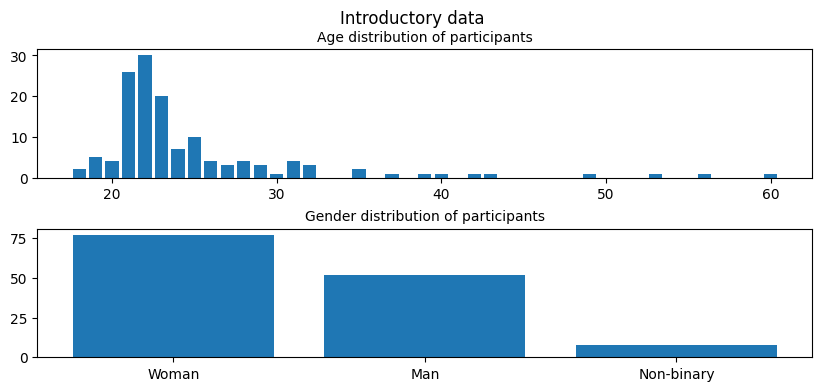

In [5]:
# print(df.columns)
age_counts = df['Age'].value_counts().sort_index()
gender_counts = df['Gender'].value_counts()

# fake data
fs = 10  # fontsize
fig, axs = plt.subplots(nrows=2, figsize=(10, 4))

axs[0].bar(age_counts.index, age_counts)
axs[0].set_title('Age distribution of participants', fontsize=fs)

axs[1].bar(gender_counts.index, gender_counts)
axs[1].set_title('Gender distribution of participants', fontsize=fs)

fig.suptitle("Introductory data")
fig.subplots_adjust(hspace=0.4)
plt.show()

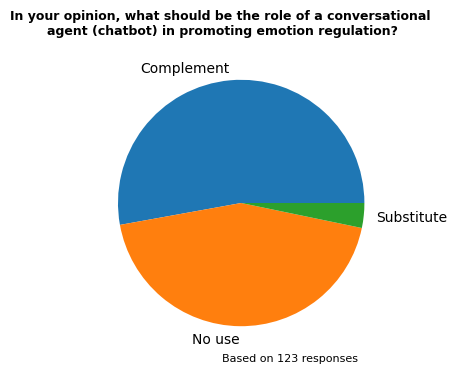

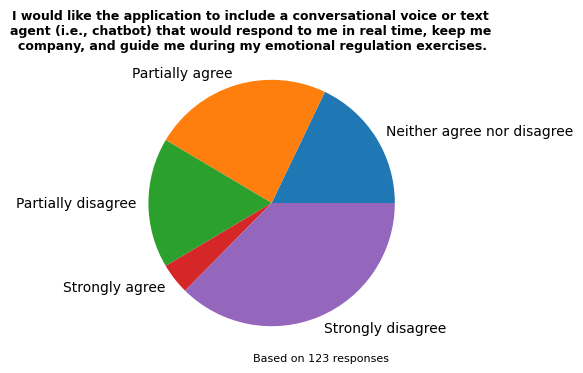

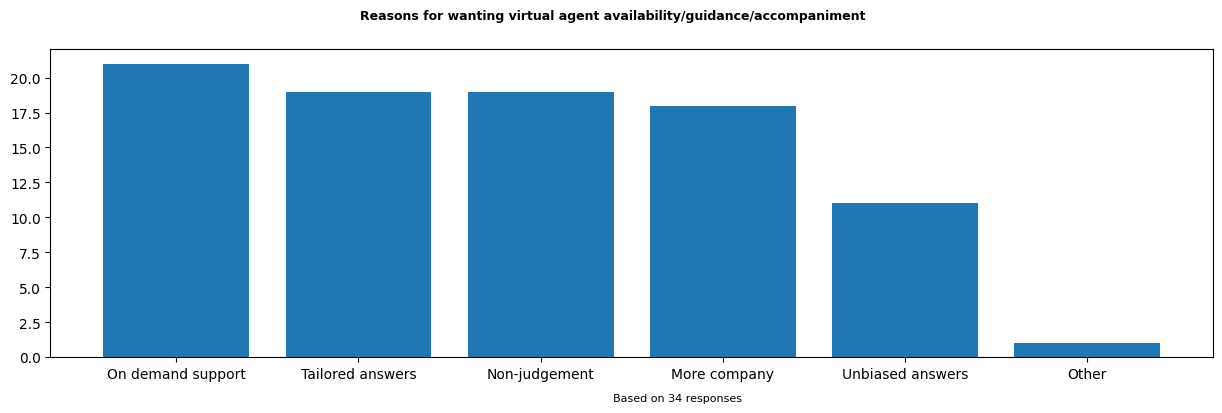

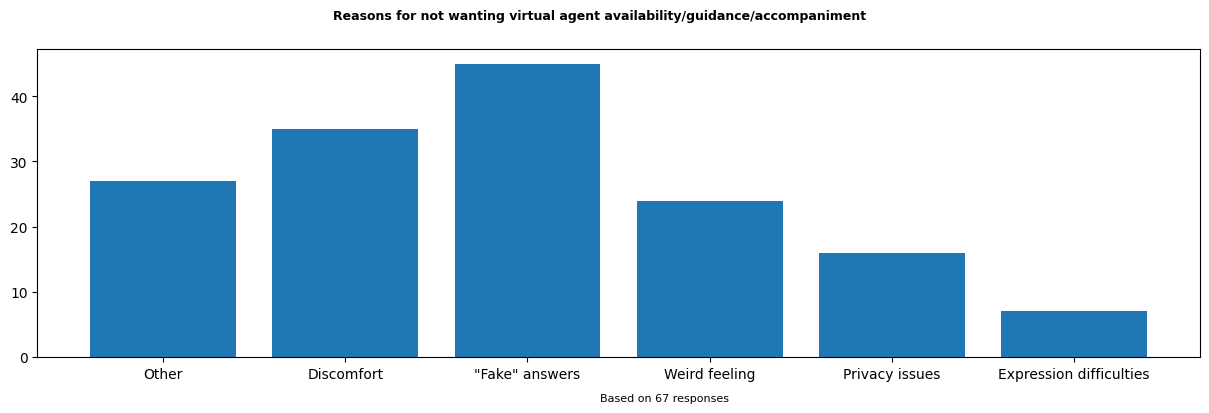

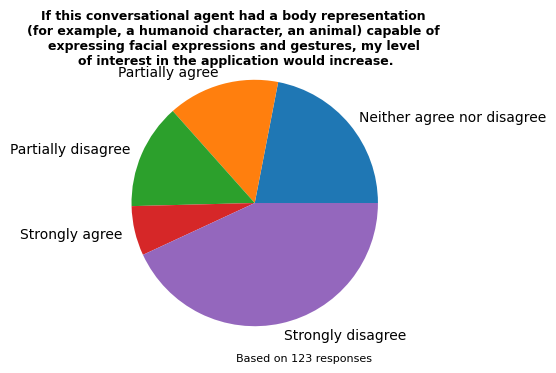

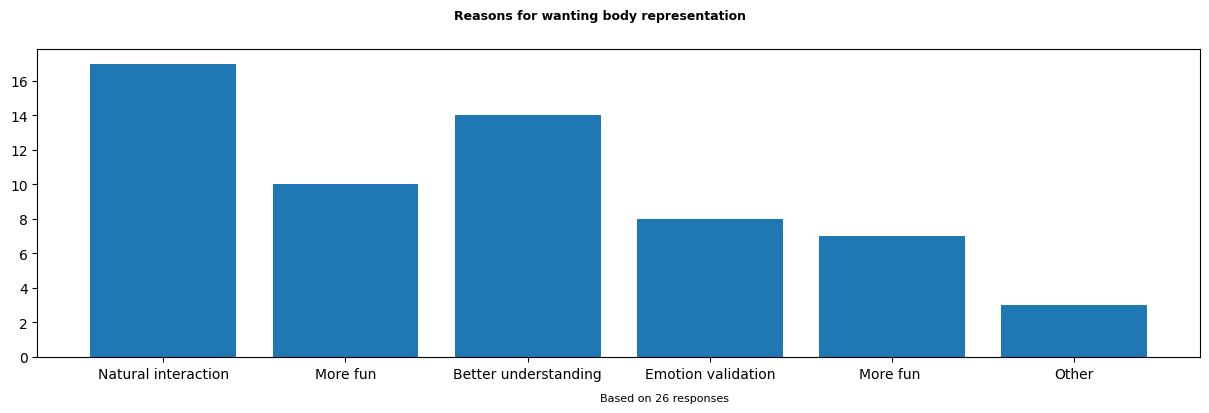

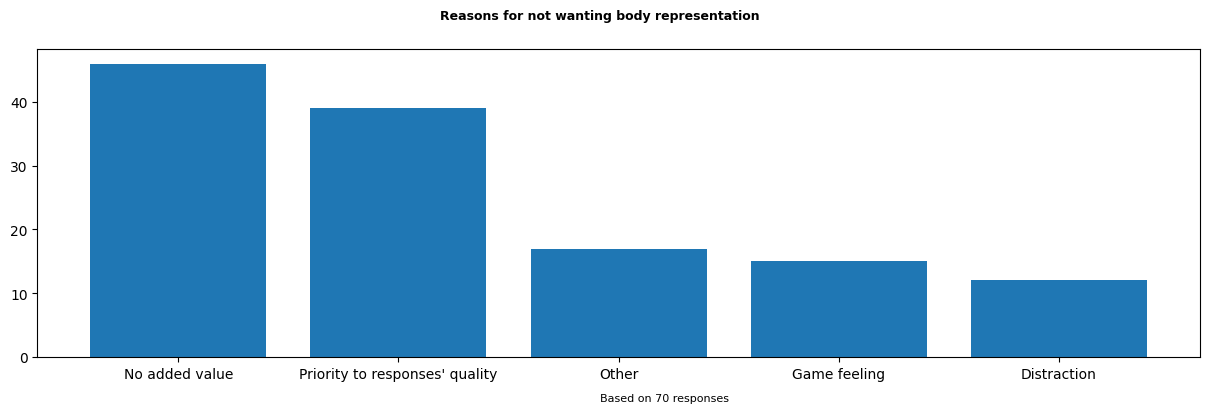

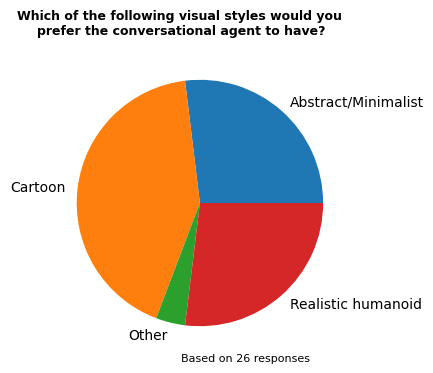

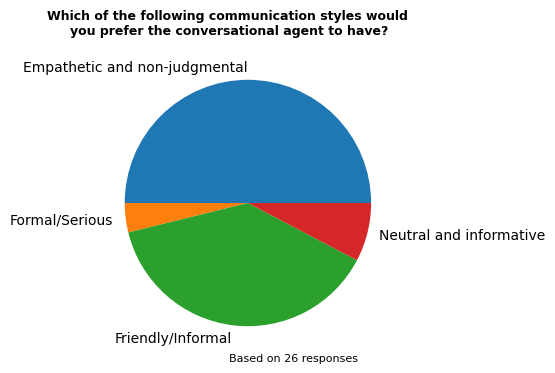

In [6]:
aa_role = {
    'role': ('AA_role', 'pie', 'In your opinion, what should be the role of a conversational \nagent (chatbot) in promoting emotion regulation?'),
    'include': ('AA_include?', 'pie', 'I would like the application to include a conversational voice or text \nagent (i.e., chatbot) that would respond to me in real time, keep me \ncompany, and guide me during my emotional regulation exercises.'),
    'yes_why': ('If yes, why?', 'bar', 'Reasons for wanting virtual agent availability/guidance/accompaniment'),
    #'yes_why_text': 'If yes, why?_6_TEXT',
    'no_why': ('If not, why?', 'bar', 'Reasons for not wanting virtual agent availability/guidance/accompaniment'),
    # 'no_why_text': 'If not, why?_6_TEXT',
 }

aa_embodied = {
    'body_likert': ('AA embodied_include?', 'pie', 'If this conversational agent had a body representation \n(for example, a humanoid character, an animal) capable of \nexpressing facial expressions and gestures, my level \nof interest in the application would increase.'),
    'yes_why': ('If yes, why?.1', 'bar', 'Reasons for wanting body representation'),
    #'yes_why_text': 'If yes, why?_5_TEXT',
    'no_why': ('If not, why?.1', 'bar', 'Reasons for not wanting body representation'),
    # 'no_why_text': 'If not, why?_5_TEXT',
 }

appearance = {
    'app': ('Appearance', 'pie', 'Which of the following visual styles would you \nprefer the conversational agent to have?'),
    #'app_text': 'Appearance_5_TEXT',
}

comm_style = {
    'comm': ('Communication style.1', 'pie', 'Which of the following communication styles would \nyou prefer the conversational agent to have?'),
    #'comm_text': 'Communication style_6_TEXT',
}

def split_compound_responses(data):
    data_dict = {}
    value_counts = data.value_counts()
    for entry in value_counts.index:
        keys = entry.split(',')
        for key in keys:
            if not (key in data_dict.keys()):
                data_dict[key] = 0
    # print(data_dict)

    for entry in data:
        if type(entry) == str:
            keys = entry.split(',')
            for key in keys:
                data_dict[key] += 1

    return data_dict

questions_array = [aa_role, aa_embodied, appearance, comm_style]
for question in questions_array:
    for figure in question.keys():
        fig, ax = plt.subplots(figsize=(15, 4))
        data = df[question[figure][0]].value_counts().sort_index()

        if question[figure][1] == 'bar':
            # print(question[figure][2])
            # print(question[figure][1])
            # print(data.index)
            # print(data)
            data_dict = split_compound_responses(df[question[figure][0]])

            ax.bar(data_dict.keys(), data_dict.values())
            plt.figtext(0.5, 0.0, f"Based on {sum(data)} responses", fontsize=8)
        elif question[figure][1] == 'pie':
            ax.pie(data, labels=data.index)
            plt.figtext(0.5, 0.1, f"Based on {sum(data)} responses", fontsize=8)
        fig.suptitle(question[figure][2], fontsize=9, fontweight='bold')
        plt.show()

In [7]:
#Split by gender
df_m = df[df['Gender'] =='Man']
df_m.name = 'Man'
df_w = df[df['Gender'] =='Woman']
df_w.name = 'Woman'
df_x = df[df['Gender'] =='Non-binary']
df_x.name = 'Non-binary'
dfs = [df_m, df_w, df_x]

#Calculate statistics
nominal = ['AA_role', 'Appearance', 'Communication style.1']
compound_nominal = ['If yes, why?', 'If not, why?', 'If yes, why?.1', 'If not, why?.1']
ordinal = ['AA_include?', 'AA embodied_include?']

for dv in nominal:
    contingency_df = df_m[dv].value_counts().sort_index().rename(df_m.name).to_frame()
    for split_df in dfs[1:]:
        contingency_df = contingency_df.join(split_df[dv].value_counts().sort_index().rename(split_df.name).to_frame(), how='left')
    contingency_df = contingency_df.fillna(0)
    display(contingency_df.head())
    chisquare = scipy.stats.chisquare(contingency_df, axis=None)
    print(f"Chi-square statistic for {dv}: {chisquare.statistic}")
    print(f"Chi-square p-value for {dv}: {chisquare.pvalue}")


,Man,Woman,Non-binary
AA_role,,,
Complement,25,38,2.0
No use,22,27,5.0
Substitute,2,2,0.0


Chi-square statistic for AA_role: 119.85365853658539
Chi-square p-value for AA_role: 3.5541675133400793e-22


,Man,Woman,Non-binary
Appearance,,,
Abstract/Minimalist,2,5.0,0.0
Cartoon,4,7.0,0.0
Other,1,0.0,0.0
Realistic humanoid,2,5.0,0.0


Chi-square statistic for Appearance: 31.230769230769237
Chi-square p-value for Appearance: 0.0010123064202843836


,Man,Woman,Non-binary
Communication style.1,,,
Empathetic and non-judgmental,4,9,0.0
Friendly/Informal,4,6,0.0
Neutral and informative,1,1,0.0


Chi-square statistic for Communication style.1: 29.360000000000007
Chi-square p-value for Communication style.1: 0.0002741155250942536
